# Predicting Hospital Admission at Emergency Department Triage
### Capstone Initial Report and Exploratory Data Analysis 



I work as an emergency physician, and a question that comes up on almost every shift is whether the
patient in front of me is going to end up admitted. In this notebook I try to answer a version of
that question with data: can I predict, using only what is known at the moment of triage, whether an
ED patient will be admitted to the hospital?

I organized the work using the CRISP-DM process: business understanding, data understanding, data
preparation, exploratory analysis, a baseline model, and evaluation.

## 1. Business Understanding

ED crowding is a patient-safety problem, and a large part of it is boarding: admitted patients
waiting in the ED for an inpatient bed. The decision to admit is often not final until labs and
imaging come back, which can be hours after the patient arrives. An estimate of admission probability
at triage would let bed managers start working on placement earlier.

This is a binary classification problem. The target is `disposition`, treated as Admit (1) versus
Discharge (0). Each row is one ED visit, and the prediction is meant to be made at the end of the
triage assessment, before any labs or imaging are ordered.

The main constraint in this project is avoiding leakage. Because the prediction is made at triage,
the model can only use information that exists at that point. Lab results, imaging counts, and
repeated in-department vital signs are generated later, during the workup that follows triage.
Including them would let the model use information from after the admission decision to predict it,
so I exclude them. Section 4.1 describes how I separated what is available at triage from what is not.

This is a prediction problem, not a causal one. The model estimates who is likely to be admitted. It
does not establish whether acting on the prediction changes any outcome, which would require a
prospective trial. I return to this in the limitations.

## 2. Setup

In [1]:

import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="Set2")

=
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42
DATA_PATH = ("/Users/Justin/Library/Mobile Documents/com~apple~CloudDocs/"
             "Education/Berkeley ML Course/capstone/hospital_triage_and_patient_history.csv")
IMG_DIR = "../images"  

## 3. Data Understanding

The data is the publicly available, de-identified Yale ED cohort from Hong, Haimovich, and
Taylor (PLoS ONE 2018; 13(7):e0201016). Each row is an ED visit, with demographics, triage vitals,
chief complaints, prior medical history, prior utilization, and, from the full workup, lab and
imaging summaries.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"{df.shape[0]:,} visits  x  {df.shape[1]:,} columns")
df.dtypes.value_counts()

560,486 visits  x  972 columns


float64    955
object      15
int64        2
Name: count, dtype: int64

### 3.1 Target distribution

                  n    pct
disposition               
Discharge    393848  70.27
Admit        166638  29.73

Class imbalance (Discharge:Admit) = 2.36 : 1


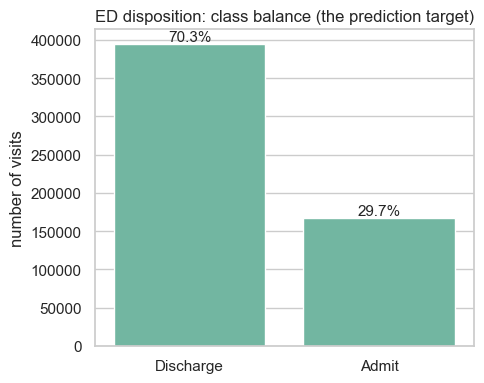

In [3]:
target_counts = df["disposition"].value_counts()
target_pct = df["disposition"].value_counts(normalize=True).mul(100).round(2)
summary = pd.DataFrame({"n": target_counts, "pct": target_pct})
print(summary)
print(f"\nClass imbalance (Discharge:Admit) = {target_counts['Discharge']/target_counts['Admit']:.2f} : 1")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="disposition", data=df, order=["Discharge", "Admit"], ax=ax)
ax.set_title("ED disposition: class balance (the prediction target)")
ax.set_xlabel(""); ax.set_ylabel("number of visits")
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(df)*100:.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig01_target_balance.png", dpi=120); plt.show()

About 30% of visits end in admission, so the classes are moderately imbalanced but not severely so.
This affects how I evaluate the model. A model that predicts "discharge" for every patient would be
about 70% accurate while providing no useful information, so I do not use accuracy as the primary
metric.

### 3.2 Missing values

Columns by missingness:
0% (complete)    380
0-10%            204
10-50%            34
50-90%           234
90-100%          120
Name: count, dtype: int64


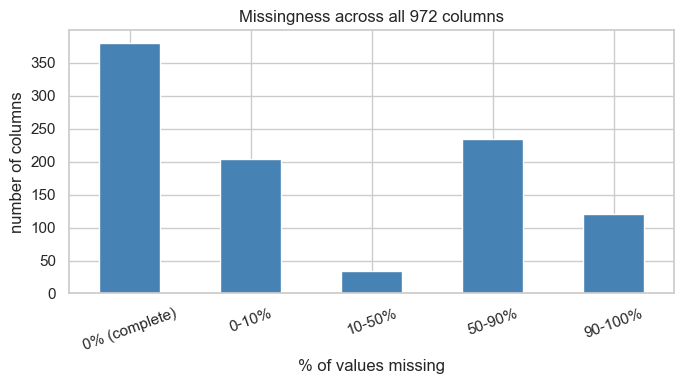

In [4]:
miss_pct = (df.isna().mean() * 100)
bins = [-0.01, 0, 10, 50, 90, 100.01]
labels = ["0% (complete)", "0-10%", "10-50%", "50-90%", "90-100%"]
miss_buckets = pd.cut(miss_pct, bins=bins, labels=labels).value_counts().reindex(labels)
print("Columns by missingness:"); print(miss_buckets)

fig, ax = plt.subplots(figsize=(7, 4))
miss_buckets.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Missingness across all 972 columns")
ax.set_xlabel("% of values missing"); ax.set_ylabel("number of columns")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(f"{IMG_DIR}/fig02_missingness.png", dpi=120); plt.show()

In [5]:
# columns with the most missing values
miss_pct.sort_values(ascending=False).head(10).round(1)

phencyclidine(pcp)screen,urine,noconf._median    100.0
phencyclidine(pcp)screen,urine,noconf._max       100.0
phencyclidine(pcp)screen,urine,noconf._min       100.0
phencyclidine(pcp)screen,urine,noconf._last      100.0
benzodiazepinesscreen,urine,noconf._last         100.0
epithelialcells_last                             100.0
benzodiazepinesscreen,urine,noconf._min          100.0
benzodiazepinesscreen,urine,noconf._median       100.0
benzodiazepinesscreen,urine,noconf._max          100.0
epithelialcells_min                              100.0
dtype: float64

The missingness falls into two groups. About 380 columns are completely filled in, and about 350
are more than half empty. The most empty columns are almost all lab values such as troponin,
d-dimer, and BNP. A lab is missing when it was not ordered, and whether a lab is ordered is decided
after triage, during the workup. So the most-missing columns are also the ones most likely to leak
the outcome, which is the basis for the feature selection in 4.1.

## 4. Data Preparation

### 4.1 Leakage-safe feature selection

This is the central decision in the project. I reviewed every column and asked whether its value is
known at the moment triage ends. I kept the columns that are, and dropped the ones that only exist
after the workup.

What I kept (available at triage):
- Demographics and context: department, age, gender, ethnicity, race, language, marital and
  employment status, insurance, and how and when the patient arrived. This group also includes ESI,
  the acuity score the triage nurse assigns.
- Triage vitals (`triage_vital_*`), which are measured at triage by definition.
- Chief complaints (`cc_*`), recorded at triage.
- Prior medical history: the CCS diagnosis flags and E-codes, which come from past encounters.
- Prior medication classes (`meds_*`) and prior utilization (`previousdispo`, `n_edvisits`,
  `n_admissions`, `n_surgeries`), all of which pre-date this visit.

What I dropped (generated after triage, so a leakage risk):
- Lab aggregates (the `_last`, `_min`, `_max`, `_median` columns), since labs are ordered during the
  workup.
- Lab and imaging counts (`_count`, `_npos`). Ordering a test is itself a downstream consequence of
  the decision to work the patient up.
- Repeated in-department vitals (`pulse_last`, `sbp_median`, and so on), which are trended over the
  whole visit. I keep the triage snapshot instead.

I also dropped `religion`, which is about a quarter missing and has no clinical reason to predict
admission.

In [6]:
# Bucket columns by name pattern. The suffixes below mark post-triage (workup) measurements.
LEAK_SUFFIX = ("_last", "_min", "_max", "_median", "_count", "_npos")

demo = ["dep_name", "esi", "age", "gender", "ethnicity", "race", "lang",
        "maritalstatus", "employstatus", "insurance_status", "arrivalmode",
        "arrivalmonth", "arrivalday", "arrivalhour_bin"]          # religion intentionally dropped
triage_vitals = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
                 "triage_vital_rr", "triage_vital_o2", "triage_vital_o2_device",
                 "triage_vital_temp"]
prior_util = ["previousdispo", "n_edvisits", "n_admissions", "n_surgeries"]
cc_cols   = [c for c in df.columns if c.startswith("cc_")]
meds_cols = [c for c in df.columns if c.startswith("meds_")]

# Prior medical history: the remaining flags that are not excluded by suffix and not already grouped.
grouped = set(["disposition", "religion"] + demo + triage_vitals + prior_util + cc_cols + meds_cols)
history_flags = [c for c in df.columns
                 if c not in grouped and not c.endswith(LEAK_SUFFIX)]

leakage_safe = demo + triage_vitals + prior_util + cc_cols + meds_cols + history_flags
discarded = [c for c in df.columns if c.endswith(LEAK_SUFFIX)]

print(f"KEPT (triage-safe) : {len(leakage_safe)} features")
print(f"  demographics/context : {len(demo)}")
print(f"  triage vitals        : {len(triage_vitals)}")
print(f"  chief complaints     : {len(cc_cols)}")
print(f"  prior history flags  : {len(history_flags)}")
print(f"  prior med classes    : {len(meds_cols)}")
print(f"  prior utilization    : {len(prior_util)}")
print(f"DISCARDED (leakage): {len(discarded)} features")
print(f"Check: {len(leakage_safe)} + {len(discarded)} + 1 target + 1 religion = {len(leakage_safe)+len(discarded)+2}")

KEPT (triage-safe) : 554 features
  demographics/context : 14
  triage vitals        : 7
  chief complaints     : 200
  prior history flags  : 281
  prior med classes    : 48
  prior utilization    : 4
DISCARDED (leakage): 416 features
Check: 554 + 416 + 1 target + 1 religion = 972


### 4.2 Target encoding and duplicate check

I encode the target as 1 for Admit and 0 for Discharge, then check for exact duplicate rows.
Each row should be a distinct visit, so a fully identical row is almost certainly a data artifact,
and I drop any I find.

In [7]:
df["admitted"] = (df["disposition"] == "Admit").astype(int)

n_dup = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dup:,}")
if n_dup:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After de-duplication: {df.shape[0]:,} rows")

Exact duplicate rows: 2


After de-duplication: 560,484 rows


### 4.3 Outlier analysis on triage vitals

Vital-sign fields sometimes contain data-entry errors, such as a heart rate of zero. I review the
distributions, then set physiologically impossible values to missing so they are handled by
imputation rather than distorting the model. The temperatures center around 98, which confirms they
are recorded in Fahrenheit.

In [8]:
vital_cols = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
              "triage_vital_rr", "triage_vital_o2", "triage_vital_temp"]
df[vital_cols].describe().round(1)

,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_temp
count,394434.0,392582.0,392423.0,389999.0,289169.0,377501.0
mean,85.6,133.4,80.5,17.6,97.3,98.1
std,16.7,21.3,13.9,2.0,1.9,0.8
min,30.0,45.0,25.0,8.0,60.0,90.0
25%,74.0,119.0,71.0,16.0,96.0,97.7
50%,84.0,131.0,80.0,18.0,98.0,98.0
75%,96.0,145.0,89.0,18.0,99.0,98.4
max,280.0,312.0,214.0,69.0,99.0,106.0


Implausible values set to NaN (then imputed):
  triage_vital_hr     : 0
  triage_vital_sbp    : 1
  triage_vital_dbp    : 1
  triage_vital_rr     : 0
  triage_vital_o2     : 0
  triage_vital_temp   : 0


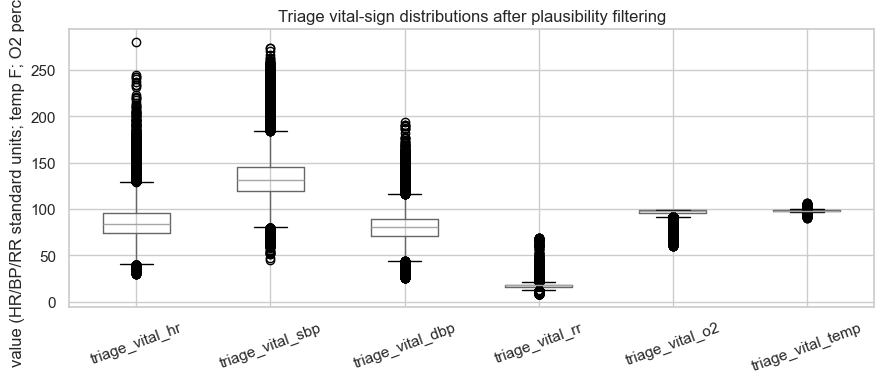

In [9]:
# Clinically plausible ranges (temperature in Fahrenheit, confirmed by the describe() above).
VITAL_RANGES = {
    "triage_vital_hr":  (20, 300),
    "triage_vital_sbp": (40, 300),
    "triage_vital_dbp": (15, 200),
    "triage_vital_rr":  (4, 80),
    "triage_vital_o2":  (50, 100),
    "triage_vital_temp": (90, 113),
}
removed = {}
for col, (lo, hi) in VITAL_RANGES.items():
    mask = (df[col] < lo) | (df[col] > hi)
    removed[col] = int(mask.sum())
    df.loc[mask, col] = np.nan
print("Implausible values set to NaN (then imputed):")
for k, v in removed.items():
    print(f"  {k:20s}: {v}")

fig, ax = plt.subplots(figsize=(9, 4))
df[vital_cols].boxplot(ax=ax)
ax.set_title("Triage vital-sign distributions after plausibility filtering")
ax.set_ylabel("value (HR/BP/RR standard units; temp F; O2 percent)")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(f"{IMG_DIR}/fig03_vital_boxplots.png", dpi=120); plt.show()

### 4.4 Feature engineering

A linear model cannot invent clinical context on its own, so I added a few features that encode
things I would reason about at the bedside:
- A missing-value flag for each triage vital. Whether a vital was even captured carries information,
  since patients who get triaged a certain way differ from those with a full set of vitals.
- Abnormal-vital flags using standard thresholds: tachycardia, hypotension, hypoxia, fever, and
  tachypnea.
- Shock index (heart rate divided by systolic blood pressure), a well-known marker of hemodynamic
  trouble.
- Simple burden counts: how many chief complaints, comorbidities, and prior medication classes a
  patient has.
- Age bands (pediatric, adult, middle-aged, elderly).

In [10]:
# missingness flag for each triage vital (whether a vital was captured is itself signal)
for col in triage_vitals:
    df[col + "_missing"] = df[col].isna().astype(int)

# abnormal-vital flags using standard clinical thresholds
df["fe_tachycardia"] = (df["triage_vital_hr"] > 100).astype(int)
df["fe_hypotension"] = (df["triage_vital_sbp"] < 90).astype(int)
df["fe_hypoxia"]     = (df["triage_vital_o2"] < 92).astype(int)
df["fe_fever"]       = (df["triage_vital_temp"] > 100.4).astype(int)
df["fe_tachypnea"]   = (df["triage_vital_rr"] > 20).astype(int)

# shock index
df["fe_shock_index"] = df["triage_vital_hr"] / df["triage_vital_sbp"]

# burden counts
df["fe_n_chief_complaints"] = df[cc_cols].sum(axis=1)
df["fe_n_comorbidities"]    = df[history_flags].sum(axis=1)
df["fe_n_med_classes"]      = df[meds_cols].sum(axis=1)

# age bands
df["fe_age_group"] = pd.cut(df["age"], [0, 18, 40, 65, 200],
                            labels=["peds", "adult", "middle", "elderly"], right=False)

engineered_numeric = ["fe_shock_index", "fe_n_chief_complaints",
                      "fe_n_comorbidities", "fe_n_med_classes"]
engineered_binary  = ["fe_tachycardia", "fe_hypotension", "fe_hypoxia",
                      "fe_fever", "fe_tachypnea"] + [c + "_missing" for c in triage_vitals]
print(f"Added {len(engineered_numeric) + len(engineered_binary) + 1} engineered features.")
df[engineered_numeric].describe().round(2)

Added 17 engineered features.


,fe_shock_index,fe_n_chief_complaints,fe_n_comorbidities,fe_n_med_classes
count,391635.00,560484.00,560484.00,560484.00
mean,0.66,1.13,5.75,2.15
std,0.17,0.40,5.56,4.79
min,0.15,0.00,0.00,0.00
25%,0.54,1.00,1.00,0.00
50%,0.64,1.00,4.00,0.00
75%,0.75,1.00,9.00,1.00
max,3.04,7.00,75.00,50.00


## 5. Exploratory Data Analysis

Now I look at how the triage features relate to admission. The natural quantity to track is the
admission rate, which is just the average of the 0/1 target within each group.

### 5.1 Admission rate by ESI

     mean   count
esi              
1.0  85.6    5271
2.0  55.0  163532
3.0  29.1  236229
4.0   2.2  125003
5.0   0.4   27992


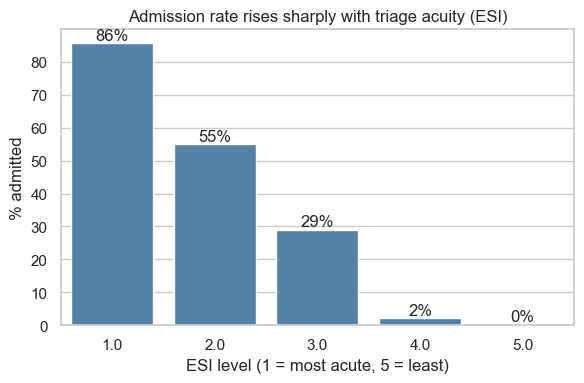

In [11]:
esi_rate = df.groupby("esi")["admitted"].agg(["mean", "count"])
esi_rate["mean"] *= 100
print(esi_rate.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=esi_rate.index, y=esi_rate["mean"], ax=ax, color="steelblue")
ax.set_title("Admission rate rises sharply with triage acuity (ESI)")
ax.set_xlabel("ESI level (1 = most acute, 5 = least)"); ax.set_ylabel("% admitted")
for i, v in enumerate(esi_rate["mean"]):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig04_esi.png", dpi=120); plt.show()

ESI shows a clean, monotonic pattern: the admission rate falls from about 86% at ESI 1 (the most
acute patients) to under 1% at ESI 5. This matches clinical expectation and suggests ESI will be a
strong predictor.

### 5.2 Admission rate by arrival mode, age, and insurance

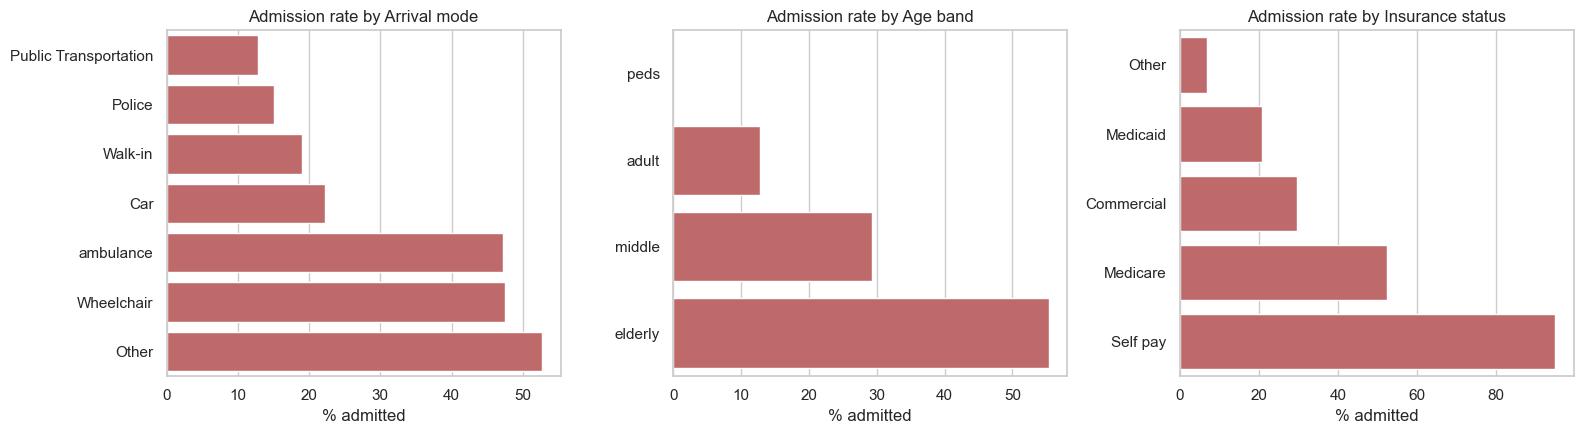

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col, title in zip(
        axes,
        ["arrivalmode", "fe_age_group", "insurance_status"],
        ["Arrival mode", "Age band", "Insurance status"]):
    rate = df.groupby(col)["admitted"].mean().sort_values() * 100
    sns.barplot(x=rate.values, y=rate.index, ax=ax, color="indianred")
    ax.set_title(f"Admission rate by {title}")
    ax.set_xlabel("% admitted"); ax.set_ylabel("")

plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig05_categoricals.png", dpi=120); plt.show()

Patients arriving by ambulance or wheelchair are admitted about half the time, compared with roughly
20% for walk-ins. The admission rate rises with age, and Medicare patients (older and sicker on
average) are admitted more often than commercially insured patients. These patterns are consistent
with clinical expectation.

### 5.3 Vitals and age by disposition

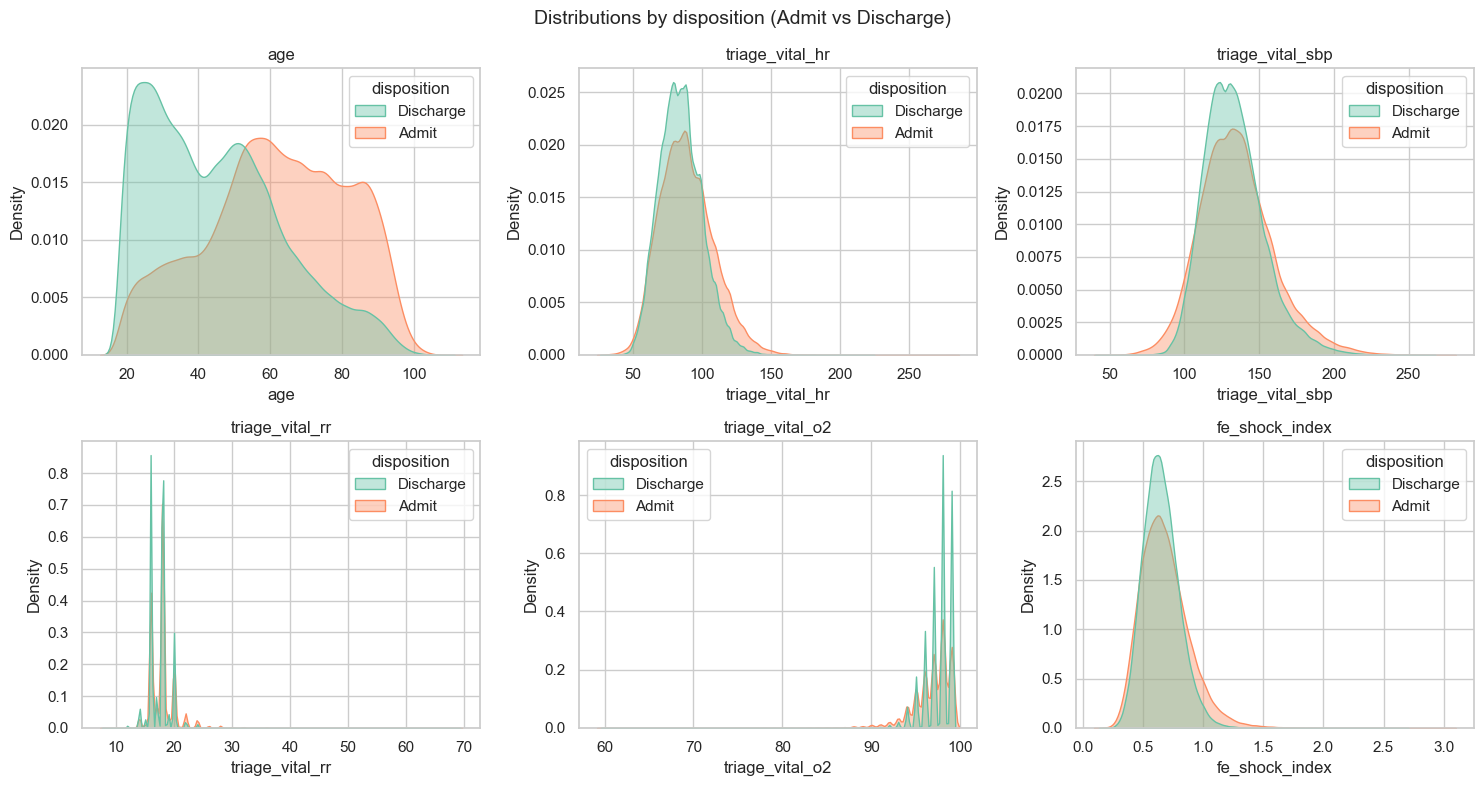

In [13]:
plot_cols = ["age", "triage_vital_hr", "triage_vital_sbp",
             "triage_vital_rr", "triage_vital_o2", "fe_shock_index"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.kdeplot(data=df, x=col, hue="disposition", common_norm=False,
                fill=True, alpha=0.4, ax=ax)
    ax.set_title(col)
fig.suptitle("Distributions by disposition (Admit vs Discharge)", fontsize=14)
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig06_continuous.png", dpi=120); plt.show()

Admitted patients tend to be older, with higher heart and respiratory rates, lower oxygen
saturation, and a higher shock index, consistent with a sicker population.

### 5.4 Admission rate by chief complaint

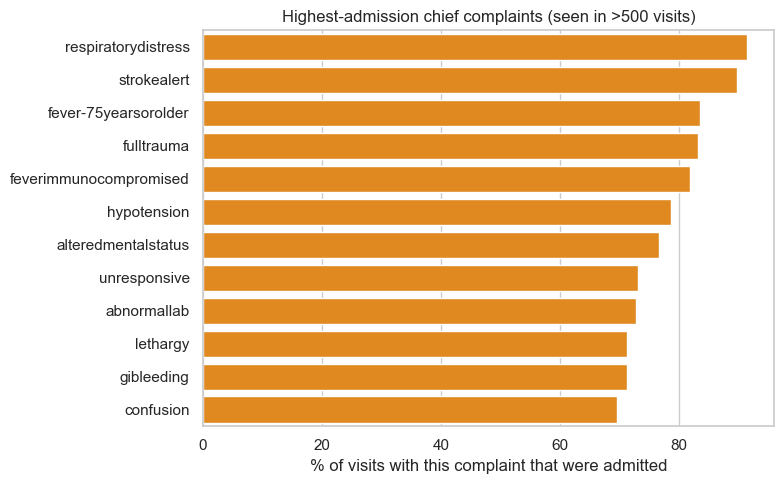

cc_respiratorydistress       91.5
cc_strokealert               89.8
cc_fever-75yearsorolder      83.5
cc_fulltrauma                83.3
cc_feverimmunocompromised    81.8
cc_hypotension               78.7
cc_alteredmentalstatus       76.8
cc_unresponsive              73.2
cc_abnormallab               72.9
cc_lethargy                  71.3
cc_gibleeding                71.3
cc_confusion                 69.6
dtype: float64

In [14]:
# Admission rate among visits flagged with each complaint (only complaints seen in >500 visits).
cc_rate = pd.Series({c: df.loc[df[c] == 1, "admitted"].mean() for c in cc_cols}) * 100
cc_n    = pd.Series({c: int(df[c].sum()) for c in cc_cols})
top = cc_rate[cc_n > 500].sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top.values, y=[c.replace("cc_", "") for c in top.index], ax=ax, color="darkorange")
ax.set_title("Highest-admission chief complaints (seen in >500 visits)")
ax.set_xlabel("% of visits with this complaint that were admitted"); ax.set_ylabel("")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig07_complaints.png", dpi=120); plt.show()
top.round(1)

### 5.5 Comorbidity burden by disposition

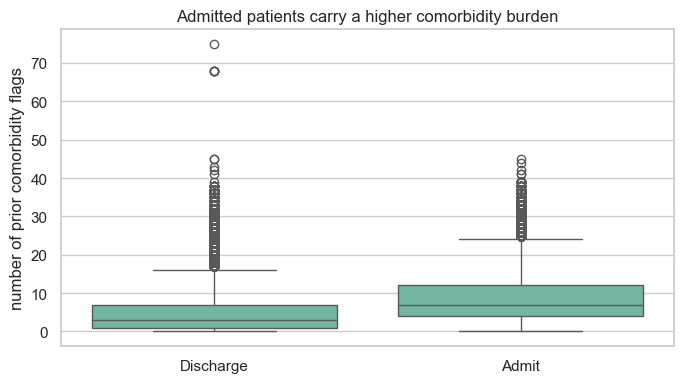

,count,mean,std,min,25%,50%,75%,max
disposition,,,,,,,,
Admit,166638.0,8.18,6.05,0.0,4.0,7.0,12.0,45.0
Discharge,393846.0,4.72,4.99,0.0,1.0,3.0,7.0,75.0


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="disposition", y="fe_n_comorbidities", order=["Discharge", "Admit"], ax=ax)
ax.set_title("Admitted patients carry a higher comorbidity burden")
ax.set_xlabel(""); ax.set_ylabel("number of prior comorbidity flags")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig08_comorbidity.png", dpi=120); plt.show()
df.groupby("disposition")["fe_n_comorbidities"].describe().round(2)

## 6. Baseline Model

### 6.1 Building the modeling matrix

I split the features into three groups and handle each one appropriately:
- Numeric features (ESI, age, triage vitals, utilization counts, the engineered numerics) get
  median imputation. The missingness itself is already captured by the flags from 4.4.
- Binary flags (chief complaints, comorbidities, meds, engineered flags) get filled with 0.
- Categorical features get one-hot encoded, with missing values kept as their own "Missing"
  category, since an unknown arrival mode is itself informative.

In [16]:
numeric_feats = (["esi", "age"] + vital_cols + ["n_edvisits", "n_admissions", "n_surgeries"]
                 + engineered_numeric)
binary_feats  = cc_cols + meds_cols + history_flags + engineered_binary
categorical_feats = ["dep_name", "gender", "ethnicity", "race", "lang", "maritalstatus",
                     "employstatus", "insurance_status", "arrivalmode", "arrivalmonth",
                     "arrivalday", "arrivalhour_bin", "triage_vital_o2_device",
                     "previousdispo", "fe_age_group"]

X_num = df[numeric_feats].fillna(df[numeric_feats].median())
X_bin = df[binary_feats].fillna(0).astype("float32")
X_cat = pd.get_dummies(df[categorical_feats].astype("object").fillna("Missing"), drop_first=True)

X = pd.concat([X_num, X_bin, X_cat], axis=1).astype("float32")
y = df["admitted"].values
print(f"Modeling matrix: {X.shape[0]:,} rows x {X.shape[1]:,} features")

Modeling matrix: 560,484 rows x 636 features


### 6.2 Train/test split, scaling, and two baselines

I use a stratified 80/20 split so both sets keep the same 30% admission rate, then standardize the
features. I fit two models. The first is a DummyClassifier that predicts the majority class, which
sets a floor that a useful model must exceed. The second is logistic regression, chosen as the
baseline because it is interpretable: the coefficients can be read directly and checked against
clinical expectation. I set `class_weight="balanced"` to account for the imbalance.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f"train={X_train.shape[0]:,}  test={X_test.shape[0]:,}  "
      f"(admit rate train={y_train.mean():.3f}, test={y_test.mean():.3f})")

scaler = StandardScaler(with_mean=False)   # keeps the many binary columns sparse-friendly
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

dummy = DummyClassifier(strategy="most_frequent").fit(X_train_s, y_train)
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")
logreg.fit(X_train_s, y_train)
print("Models fit.")

train=448,387  test=112,097  (admit rate train=0.297, test=0.297)


Models fit.


### 6.3 Evaluation

Because the classes are imbalanced (about 70/30), accuracy is not a useful headline metric: a model
that always predicts "discharge" would score about 70%. I report three metrics instead:
- AUROC, which measures how well the model ranks patients by risk independent of any threshold, and
  is the standard metric for clinical risk scores.
- AUPRC (average precision), which is more sensitive to performance on the minority class, the
  admitted patients.
- Sensitivity, together with the full confusion matrix. Clinically, missing a patient who needed
  admission (a false negative) is worse than a false alarm, so I want to see how many true admissions
  the model catches at the working threshold.

In [18]:
proba = logreg.predict_proba(X_test_s)[:, 1]
dummy_proba = dummy.predict_proba(X_test_s)[:, 1]

auroc = roc_auc_score(y_test, proba)
auprc = average_precision_score(y_test, proba)
dummy_auroc = roc_auc_score(y_test, dummy_proba)
prevalence = y_test.mean()

print(f"Dummy (majority class)   AUROC = {dummy_auroc:.3f}")
print(f"Logistic Regression      AUROC = {auroc:.3f}")
print(f"Logistic Regression      AUPRC = {auprc:.3f}   (baseline = prevalence = {prevalence:.3f})")

Dummy (majority class)   AUROC = 0.500
Logistic Regression      AUROC = 0.921
Logistic Regression      AUPRC = 0.852   (baseline = prevalence = 0.297)


In [19]:
# 5-fold stratified CV on the full data to confirm the score is stable, not a lucky split.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(
    LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs"),
    scaler.fit_transform(X), y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"5-fold CV AUROC: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")

5-fold CV AUROC: 0.921 +/- 0.001


Sensitivity (recall, admit) = 0.814
Specificity                 = 0.857
Precision (PPV, admit)      = 0.706


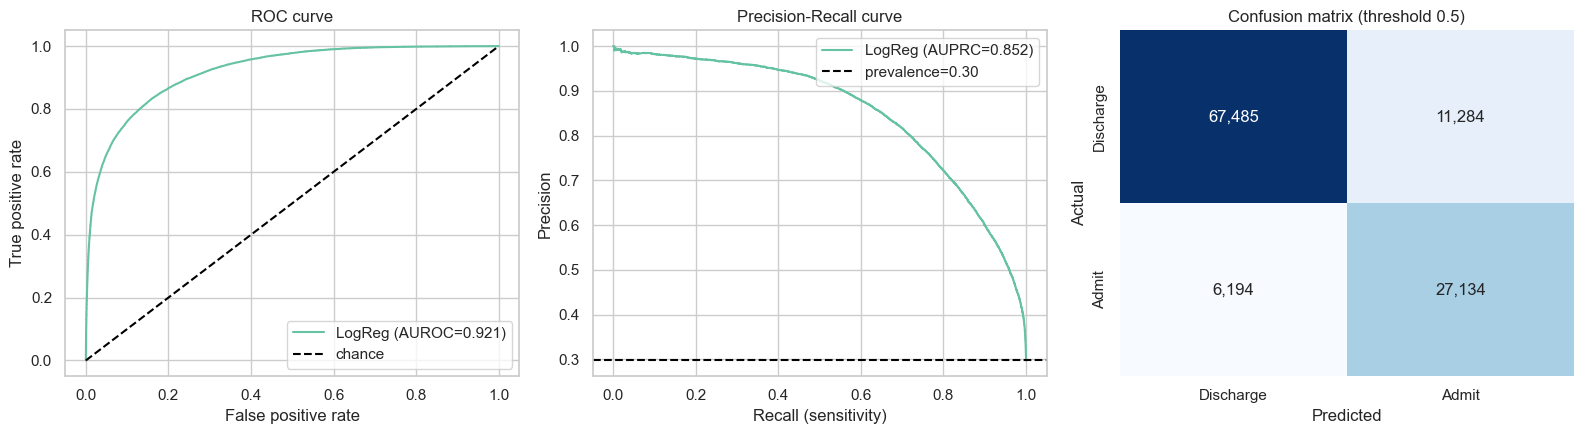

In [20]:
# Confusion matrix and sensitivity/specificity at the default 0.5 threshold.
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
print(f"Sensitivity (recall, admit) = {sensitivity:.3f}")
print(f"Specificity                 = {specificity:.3f}")
print(f"Precision (PPV, admit)      = {ppv:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# ROC
fpr, tpr, _ = roc_curve(y_test, proba)
axes[0].plot(fpr, tpr, label=f"LogReg (AUROC={auroc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", label="chance")
axes[0].set_title("ROC curve"); axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate"); axes[0].legend(loc="lower right")
# PR
prec, rec, _ = precision_recall_curve(y_test, proba)
axes[1].plot(rec, prec, label=f"LogReg (AUPRC={auprc:.3f})")
axes[1].axhline(prevalence, ls="--", color="k", label=f"prevalence={prevalence:.2f}")
axes[1].set_title("Precision-Recall curve"); axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision"); axes[1].legend(loc="upper right")
# Confusion matrix
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[2],
            xticklabels=["Discharge", "Admit"], yticklabels=["Discharge", "Admit"])
axes[2].set_title("Confusion matrix (threshold 0.5)")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig09_evaluation.png", dpi=120); plt.show()

### 6.4 Model coefficients

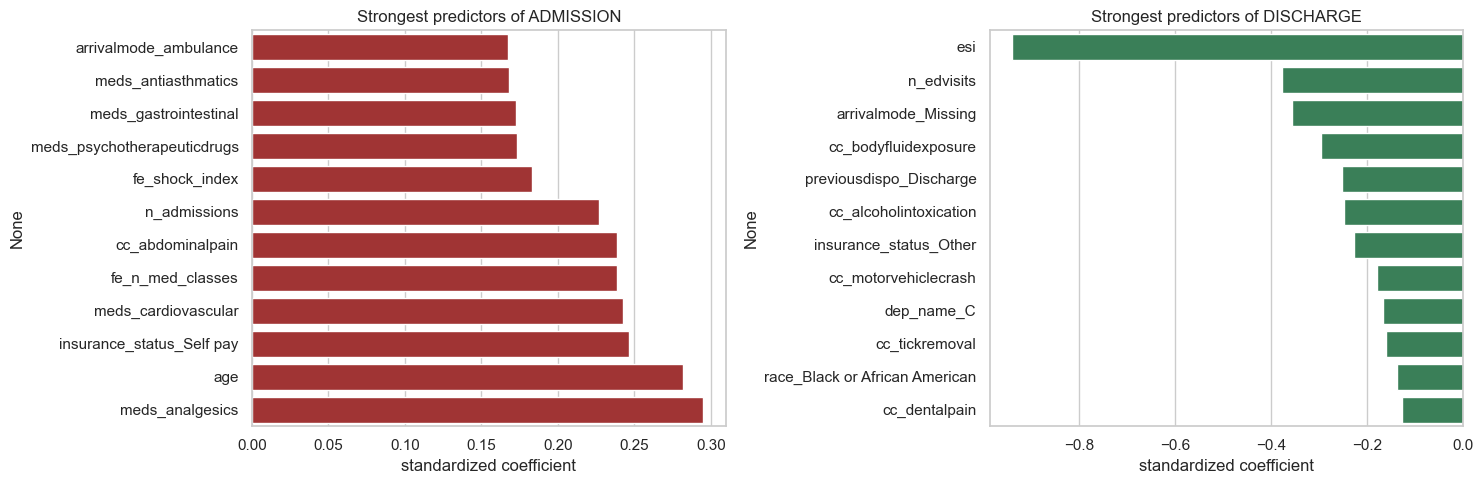

In [21]:
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
top_admit = coef.tail(12)
top_dis   = coef.head(12)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=top_admit.values, y=top_admit.index, ax=axes[0], color="firebrick")
axes[0].set_title("Strongest predictors of ADMISSION"); axes[0].set_xlabel("standardized coefficient")
sns.barplot(x=top_dis.values, y=top_dis.index, ax=axes[1], color="seagreen")
axes[1].set_title("Strongest predictors of DISCHARGE"); axes[1].set_xlabel("standardized coefficient")
plt.tight_layout(); plt.savefig(f"{IMG_DIR}/fig10_coefficients.png", dpi=120); plt.show()

## 7. Findings

A triage-only model predicts admission well. Using only what is known when triage is complete (the
acuity score, vital signs, chief complaint, age, arrival mode, and prior history), the model
separates admitted from discharged patients with an AUROC of about 0.92. In practical terms, given
one admitted and one discharged patient at random, the model assigns the admitted patient a higher
risk score about nine times out of ten.

The strongest predictors are familiar clinical ones: the ESI acuity score, arrival by ambulance,
older age, abnormal vital signs, and a heavier prior medical history. The model reflects established
clinical reasoning rather than unexpected relationships.

The model uses no lab or imaging results, since those are generated after triage and would leak the
outcome. The performance reported here is therefore a fair estimate of what is achievable at triage,
the point at which an early prediction is useful.

In practice, a score like this could flag likely admissions early enough to begin bed planning before
the workup is complete, which is where boarding delays originate.

## 8. Limitations

Prediction is not causation. The model says who is likely to be admitted. It does not show that
acting on the prediction improves outcomes or reduces boarding. That is a causal question that needs
a prospective trial, not this retrospective data.

The data is from a single health system, so ESI practices, arrival patterns, and case mix will
differ elsewhere. The model would need external validation before anyone deployed it.

There is a small residual leakage question. I kept a couple of historical fields (`previousdispo`
and `n_admissions`) because they pre-date the visit, but a more conservative version could drop them.

Finally, logistic regression is linear and cannot capture interactions.

## 9. Next steps

1. Try more flexible models. Logistic regression is a linear baseline, so the natural next move is to test models that can capture interactions and non-linear effects, such as decision trees, random forests, and gradient boosting, using cross-validation and tuned hyperparameters to see whether they improve on this baseline.
2. Choose an operating threshold. The right cutoff depends on how the score would be used, so I would tune the threshold to a clinically meaningful target (for example, catching at least 90% of admissions) and report the resulting alert volume and the trade-off between sensitivity and false alarms.
3. Check which features drive the model. Comparing the most important predictors across models would confirm that the main drivers are stable and clinically sensible rather than artifacts of one model.
4. Validate on new data. Before trusting the model in practice, I would test it on data from a different time period or a different site to see how well it holds up outside the original cohort.